<a href="https://colab.research.google.com/github/yjaiswal007/image_segmentation_with_pytorch/blob/update-notebook/Deep_Learning_with_PyTorch_ImageSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 : Set up colab gpu runtime environment

In [1]:
!pip install segmentation-models-pytorch
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00
  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-jh0mlew2
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-jh0mlew2
  Resolved https://github.com/albumentations-team/albumentations to commit 66212d77a44927a29d6a0e81621d3c27afbd929c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Attempting uninstall: albucore
    Found existing installation: albucore 0.0.24
    Uninstalling albucore-0.0.24:
      Successfully uninstalled albucore-0.0.24
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albumentations 2.0.8 requires albucore==0.0.24, but you have albucore 0.0.28 which is incompatible.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# Path to your folder inside Google Drive
folder_path = '/content/drive/My Drive/Colab_Notebooks/Image_segmentation_with_pytorch/Human-Segmentation-Dataset-master/'

# Change working directory to that folder
os.chdir(folder_path)

# Confirm path
!pwd

/content/drive/My Drive/Colab_Notebooks/Image_segmentation_with_pytorch/Human-Segmentation-Dataset-master


# Download Dataset

original author of the dataset :
https://github.com/VikramShenoy97/Human-Segmentation-Dataset


In [4]:
username, email = "yjaiswal007", "yjaiswal007@gmail.com"
!git config --global user.name "$username" && git config --global user.email "$email"

In [5]:
# !git clone https://github.com/parth1620/Human-Segmentation-Dataset-master.git

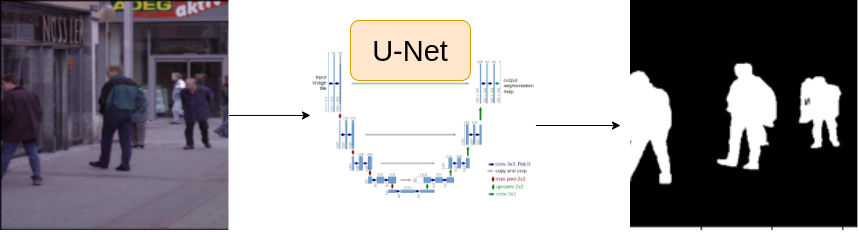

# Some Common Imports

In [6]:
import sys
# # sys.path.append('/content/Human-Segmentation-Dataset-master')
sys.path.append('/content/drive/My Drive/Colab_Notebooks/Image_segmentation_with_pytorch/Human-Segmentation-Dataset-master')

In [7]:
import os
import torch
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import helper

# Task : 2 Setup Configurations

In [8]:

dir_path = '/content/drive/My Drive/Colab_Notebooks/Image_segmentation_with_pytorch/'
csv_file = os.path.join(dir_path, r'Human-Segmentation-Dataset-master/train.csv')
data_dir = '/content/'
device = 'cuda'

epochs = 25
lr = 0.003
image_size = 320
batch_size = 16

encoder = 'timm-efficientnet-b0'
weights = 'imagenet'

In [9]:
df = pd.read_csv(csv_file)
display(df.head())
df.shape

,masks,images
0,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
1,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
2,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
3,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
4,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...


(290, 2)

In [10]:
row = df.iloc[4]

image_path = row.images
mask_path = row.masks

image = cv2.imread(os.path.join(dir_path, image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(os.path.join(dir_path, mask_path), cv2.IMREAD_GRAYSCALE) / 255.0

print(image.shape)
print(mask.shape)

(408, 612, 3)
(408, 612)


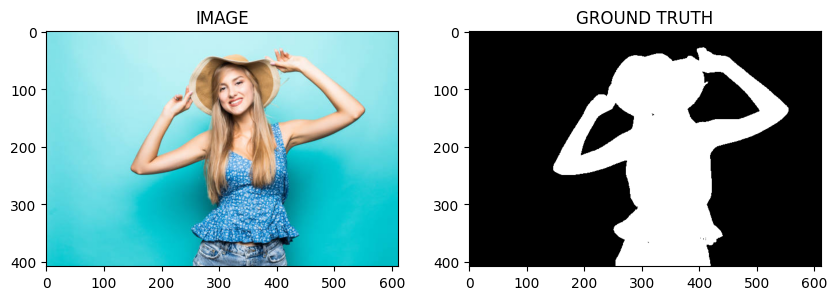

In [11]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.set_title('IMAGE')
ax1.imshow(image)

ax2.set_title('GROUND TRUTH')
ax2.imshow(mask,cmap = 'gray')

In [12]:
train_df, valid_df = train_test_split(df, test_size = 0.2, random_state = 42)

# Task 3 : Augmentation Functions

albumentation documentation : https://albumentations.ai/docs/

In [13]:
import albumentations as A

In [14]:
def get_train_augs():
  return A.Compose([
      A.Resize(image_size, image_size),
      A.HorizontalFlip(p=0.5),
      A.VerticalFlip(p=0.5),
  ])

def get_valid_augs():
  return A.Compose([
      A.Resize(image_size, image_size),
  ])

# Task 4 : Create Custom Dataset

In [15]:
from torch.utils.data import Dataset

In [16]:
class SegmentationDataset(Dataset):

  def __init__(self, df, augmentations):

    self.df = df
    self.augmentations = augmentations

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    image_path = os.path.join(dir_path, row.images)
    mask_path = os.path.join(dir_path, row.masks)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # (height,width,channel)
    mask = np.expand_dims(mask, axis=-1)

    # Resize mask if needed BEFORE albumentations
    if image.shape[:2] != mask.shape[:2]:
        mask = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask = np.expand_dims(mask, axis=-1)
    # print(image.shape, mask.shape)

    if self.augmentations:
      data = self.augmentations(image=image, mask=mask)
      image = data['image']
      mask = data['mask']

    # (h, w, c) --> (c, h, w)
    image = np.transpose(image, (2,0,1)).astype(np.float32)
    mask = np.transpose(mask, (2,0,1)).astype(np.float32)

    image = torch.Tensor(image) / 255.0
    mask = torch.round(torch.Tensor(mask) / 255.0)

    return image, mask

In [17]:
trainset = SegmentationDataset(train_df, get_train_augs())
validset = SegmentationDataset(valid_df, get_valid_augs())

In [18]:
print(f"Size of Trainset : {len(trainset)}")
print(f"Size of Validset : {len(validset)}")

Size of Trainset : 232
Size of Validset : 58


In [19]:
print(helper.__file__)

/content/drive/My Drive/Colab_Notebooks/Image_segmentation_with_pytorch/Human-Segmentation-Dataset-master/helper.py


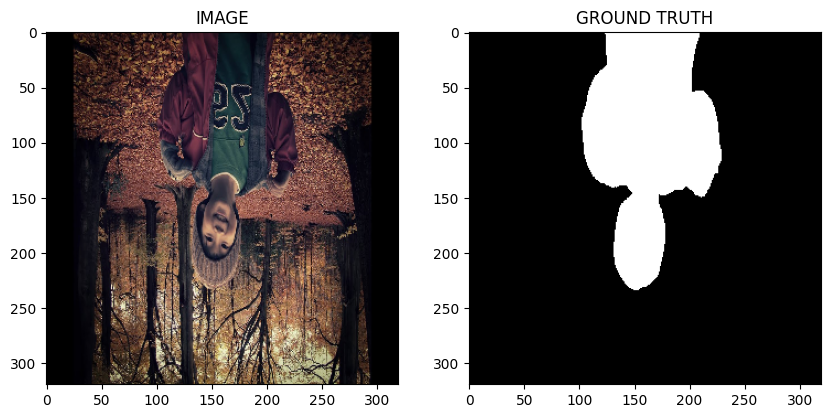

In [20]:
idx = 21

image, mask = trainset[idx]
helper.show_image(image, mask)

# Task 5 : Load dataset into batches

In [21]:
from torch.utils.data import DataLoader

In [22]:
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
validloader = DataLoader(validset, batch_size=batch_size)

In [23]:
print("Total no. of batches in trainloader: ", len(trainloader))
print("Total no. of batches in validloader: ", len(validloader))

Total no. of batches in trainloader:  15
Total no. of batches in validloader:  4


In [24]:
for image, mask in trainloader:
  break

print('One batch image shape: ', image.shape)
print('One batch mask shape: ', mask.shape)

One batch image shape:  torch.Size([16, 3, 320, 320])
One batch mask shape:  torch.Size([16, 1, 320, 320])


# Task 6 : Create Segmentation Model

segmentation_models_pytorch documentation : https://smp.readthedocs.io/en/latest/

In [25]:
from torch import nn
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss


In [26]:
class SegmentationModel(nn.Module):

  def __init__(self):
    super(SegmentationModel, self).__init__()

    self.arc = smp.Unet(
        encoder_name = encoder,
        encoder_weights = weights,
        in_channels = 3,
        classes = 1,
        activation = None
    )

  def forward(self, images, masks=None):
    logits = self.arc(images)

    if masks != None:
      loss1 = DiceLoss(mode='binary')(logits, masks)
      loss2 = nn.BCEWithLogitsLoss()(logits, masks)
      return logits, loss1 + loss2

    return logits

In [27]:
model = SegmentationModel()
model.to(device);

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

# Task 7 : Create Train and Validation Function

In [28]:
def train_fn(data_loader, model, optimizer):

  model.train()
  total_loss = 0.0

  for images, masks in tqdm(data_loader):

    images = images.to(device)
    masks = masks.to(device)

    optimizer.zero_grad()
    logits, loss = model(images, masks)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  return total_loss / len(data_loader)

In [29]:
def eval_fn(data_loader, model):

  model.eval()
  total_loss = 0.0

  with torch.no_grad():
    for images, masks in tqdm(data_loader):

      images = images.to(device)
      masks = masks.to(device)

      logits, loss = model(images, masks)

      total_loss += loss.item()

  return total_loss / len(data_loader)


# Task 8 : Train Model

In [30]:
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [31]:
best_valid_loss = np.inf

for i in range(epochs):

  train_loss = train_fn(trainloader, model, optimizer)
  valid_loss = eval_fn(validloader, model)

  if valid_loss < best_valid_loss:
    torch.save(model.state_dict(), 'best_model.pt')
    print("SAVED=MODEL")
    best_valid_loss = valid_loss

  print(f"Epoch: {i+1} Train_loss: {train_loss} Valid_loss: {valid_loss}")

100%|██████████| 4/4 [00:50<00:00, 12.68s/it]


SAVED=MODEL
Epoch: 1 Train_loss: 0.7090558727582296 Valid_loss: 0.6469512581825256


100%|██████████| 4/4 [00:01<00:00,  2.96it/s]


SAVED=MODEL
Epoch: 2 Train_loss: 0.3518489996592204 Valid_loss: 0.433353029191494


100%|██████████| 4/4 [00:01<00:00,  2.82it/s]


...

Epoch: 23 Train_loss: 0.17949497004350026 Valid_loss: 0.24882198125123978


100%|██████████| 4/4 [00:01<00:00,  3.18it/s]


SAVED=MODEL
Epoch: 24 Train_loss: 0.14849896530310314 Valid_loss: 0.19399034976959229


100%|██████████| 4/4 [00:01<00:00,  2.72it/s]

Epoch: 25 Train_loss: 0.13011136601368586 Valid_loss: 0.21025360375642776


# Task 9 : Inference

In [58]:
idx = 30

model.load_state_dict(torch.load(os.path.join(dir_path, 'Human-Segmentation-Dataset-master', 'best_model.pt')))

image, mask = validset[idx]

logits_mask = model(image.to(device).unsqueeze(0))  #(c, h, w) --> (1, c, h, w)
pred_mask = torch.sigmoid(logits_mask)
pred_mask = (pred_mask > 0.5) * 1.0


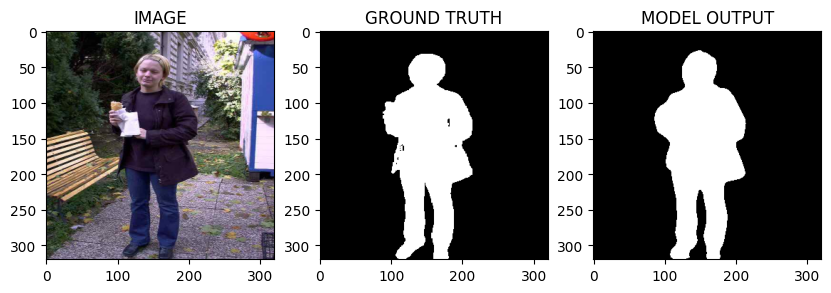

In [59]:
helper.show_image(image, mask, pred_mask.detach().cpu().squeeze(0))

In [49]:
len(validset)

58